In [28]:
# Install the graphviz system library
!apt-get install graphviz -y

# Install the graphviz Python package
!pip install graphviz
!pip install mglearn

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.


In [29]:
import mglearn
from sklearn.tree import export_graphviz
import graphviz
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The neural network model
MLPs can be viewed as generalizations of linear models that perform multiple stages
of processing to come to a decision.

Remember that the prediction by a linear regressor is given as:
ŷ = w[0] * x[0] + w[1] * x[1] + ... + w[p] * x[p] + b

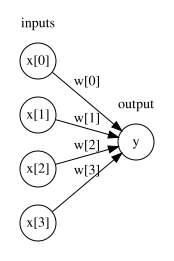

In [30]:
display(mglearn.plots.plot_logistic_regression_graph())
#Visualization of logistic regression, where input features and predictions are shown as nodes, and the coefficients are connections between the nodes



Computing a series of weighted sums is mathematically the same as computing just one weighted sum, so to make this model truly more powerful than a linear model,
we need one extra trick. After computing a weighted sum for each hidden unit, a nonlinear function is applied to the result—usually the rectifying nonlinearity (also
known as rectified linear unit or relu) or the tangens hyperbolicus (tanh).
The result of this function is then used in the weighted sum that computes the output, ŷ. The two
functions are visualized.

Text(0, 0.5, 'relu(x), tanh(x)')

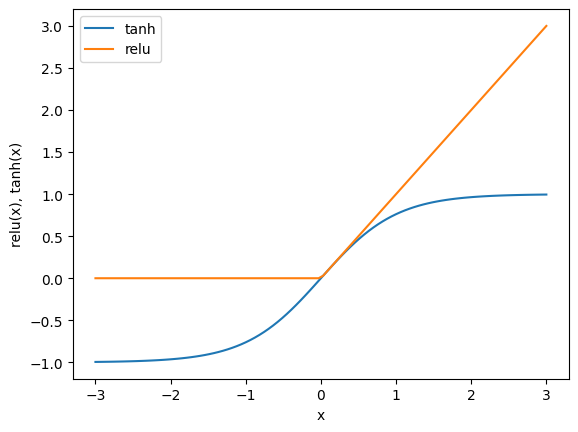

In [31]:
#The hyperbolic tangent activation function and the rectified linear activa‐tion function
line = np.linspace(-3, 3, 100)
plt.plot(line, np.tanh(line), label="tanh")
plt.plot(line, np.maximum(line, 0), label="relu")
plt.legend(loc="best")
plt.xlabel("x")
plt.ylabel("relu(x), tanh(x)")

for computing
ŷ in the case of regression would be (when using a tanh nonlinearity):
h[0] = tanh(w[0, 0] * x[0] + w[1, 0] * x[1] + w[2, 0] * x[2] + w[3, 0] * x[3] + b[0])
h[1] = tanh(w[0, 1] * x[0] + w[1, 1] * x[1] + w[2, 1] * x[2] + w[3, 1] * x[3] + b[1])
h[2] = tanh(w[0, 2] * x[0] + w[1, 2] * x[1] + w[2, 2] * x[2] + w[3, 2] * x[3] + b[2])
ŷ = v[0] * h[0] + v[1] * h[1] + v[2] * h[2] + b


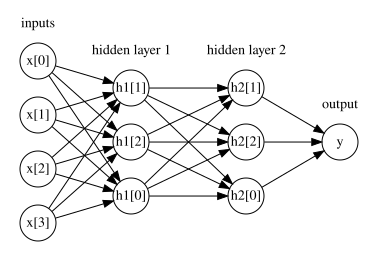

In [32]:
#It is also possible to add additional hidden layers
mglearn.plots.plot_two_hidden_layer_graph()


**Part 1. Explore NNET models with MLPClassifier**

**Tuning neural networks**





Text(0, 0.5, 'Feature 1')

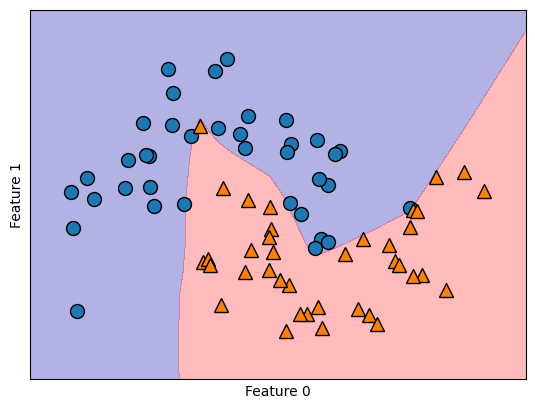

In [33]:
#MLP by applying the MLPClassifier to the two_moons dataset
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,
 random_state=42)
mlp = MLPClassifier(solver='lbfgs', random_state=0).fit(X_train, y_train)
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
#Decision boundary learned by a neural network with 100 hidden units on the two_moons dataset

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Text(0, 0.5, 'Feature 1')

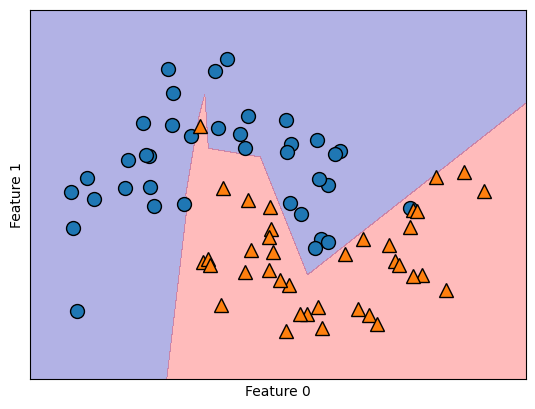

In [34]:
mlp = MLPClassifier(solver='lbfgs', random_state=0, hidden_layer_sizes=[10])
mlp.fit(X_train, y_train)
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
#Decision boundary learned by a neural network with 10 hidden units on the two_moons dataset

With only 10 hidden units, the decision boundary looks somewhat more ragged. The
default nonlinearity is relu, With a single hidden layer, this
means the decision function will be made up of 10 straight line segments. If we want
a smoother decision boundary, we could add more hidden units (
add a second hidden layer, or use the tanh nonlinearity

Text(0, 0.5, 'Feature 1')

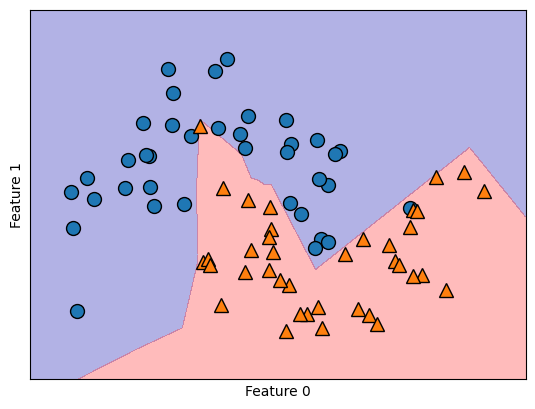

In [35]:
# using two hidden layers, with 10 units each
mlp = MLPClassifier(solver='lbfgs', random_state=0,
 hidden_layer_sizes=[10, 10])
mlp.fit(X_train, y_train)
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
#Decision boundary learned using 2 hidden layers with 10 hidden units each, with rect activation function


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Text(0, 0.5, 'Feature 1')

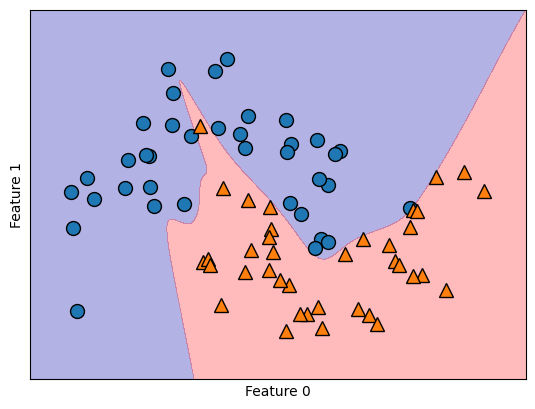

In [36]:
# using two hidden layers, with 10 units each, now with tanh nonlinearity
mlp = MLPClassifier(solver='lbfgs', activation='tanh',
 random_state=0, hidden_layer_sizes=[10, 10])
mlp.fit(X_train, y_train)
mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3)
mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
#Decision boundary learned using 2 hidden layers with 10 hidden units each, with tanh activation function


**1. Try different numbers of hidden_layer_sizes including the number of hidden layers AND the number of nodes in each layer**

---



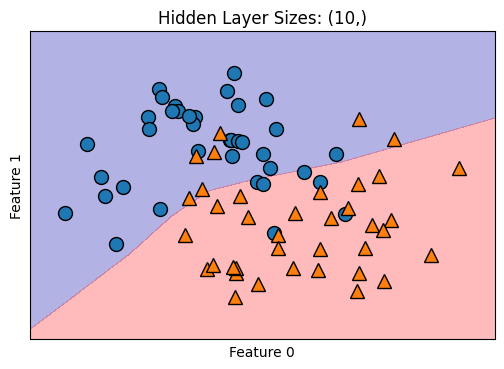

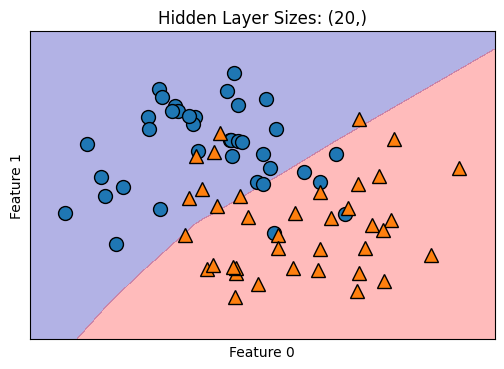

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


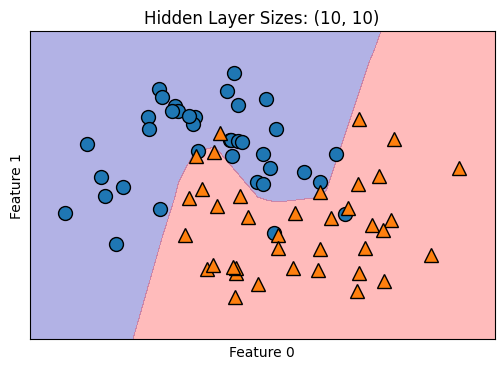

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


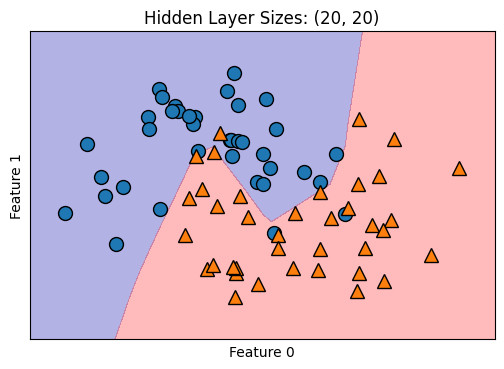

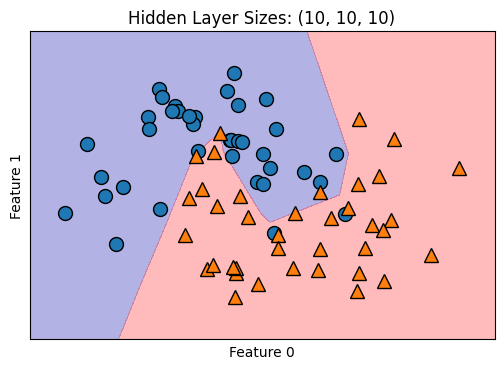

In [37]:


# Generate a synthetic dataset
X, y = make_moons(n_samples=100, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# List of different hidden layer sizes to test
hidden_layer_sizes = [(10,), (20,), (10, 10), (20, 20), (10, 10, 10)]

# Train MLPClassifier with different hidden layer sizes
for size in hidden_layer_sizes:
    mlp = MLPClassifier(hidden_layer_sizes=size, max_iter=1000, alpha=0.01, random_state=42)
    mlp.fit(X_train, y_train)

    # Plotting the decision boundaries
    plt.figure(figsize=(6, 4))
    mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=0.3)
    mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train)
    plt.title(f'Hidden Layer Sizes: {size}')
    plt.xlabel('Feature 0')
    plt.ylabel('Feature 1')
    plt.show()

**2.	Discuss the effect of the hidden_layer_sizes on the decision boundary you visualized.**

As we increase the number of layers or nodes in a Multilayer Perceptron (MLP), the model becomes better at creating intricate decision boundaries, allowing it to recognize more complex patterns in the data. However, this increased complexity can also lead to overfitting, where the model is too finely tuned to the training data and performs poorly on new, unseen data. This situation underscores the delicate balance between underfitting (where the model is too simple) and overfitting (where the model is too complex). These visual examples highlight the need to carefully select the network's architecture based on the complexity of the problem you're solving and the volume of data you have, ensuring the model is neither too simple to capture the underlying trends nor too complex to generalize well.

Finally, we can also control the complexity of a neural network by using an l2 penalty
to shrink the weights toward zero, as we did in ridge regression and the linear classifi‐
ers. The parameter for this in the MLPClassifier is alpha (as in the linear regression
models), and it’s set to a very low value (little regularization) by default

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


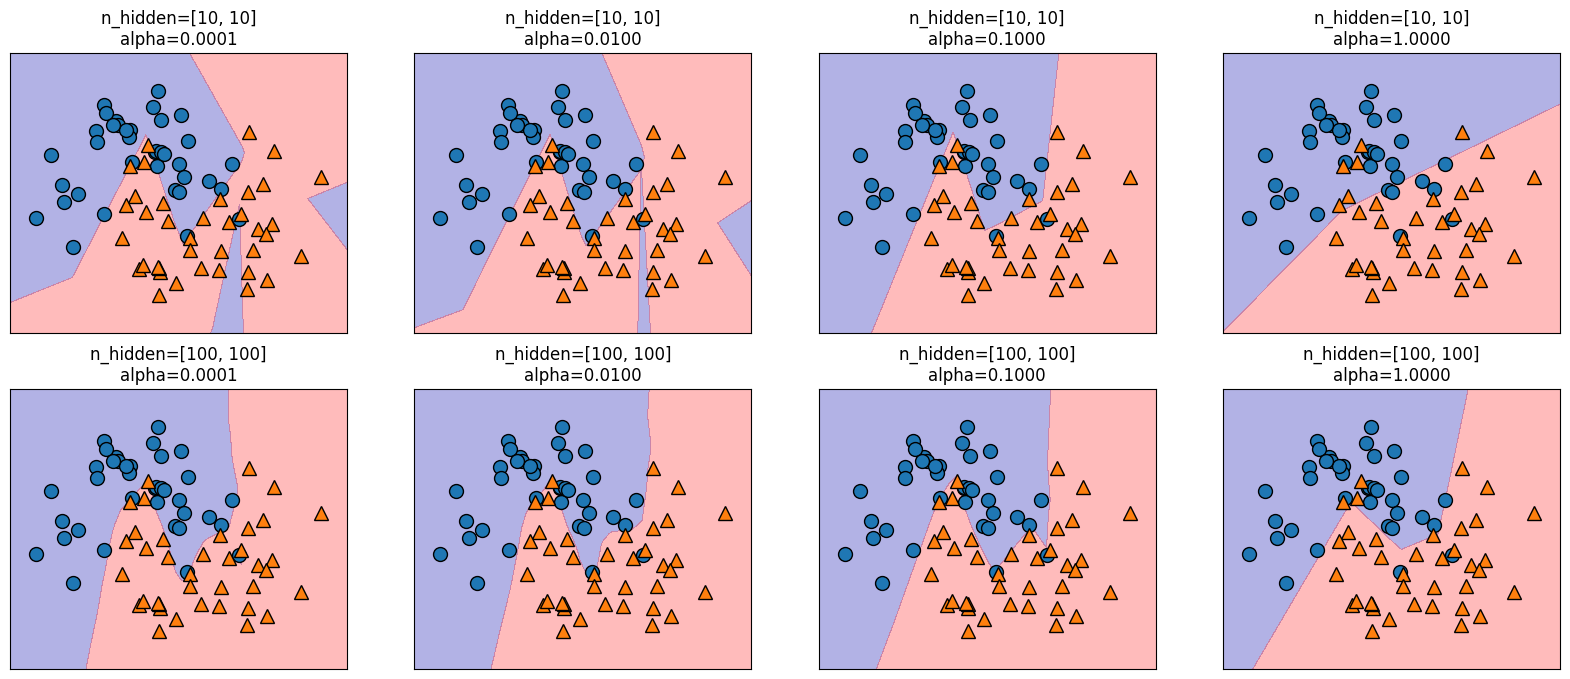

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for axx, n_hidden_nodes in zip(axes, [10, 100]):
 for ax, alpha in zip(axx, [0.0001, 0.01, 0.1, 1]):
  mlp = MLPClassifier(solver='lbfgs', random_state=0,
                      hidden_layer_sizes=[n_hidden_nodes, n_hidden_nodes], alpha=alpha)
  mlp.fit(X_train, y_train)
  mglearn.plots.plot_2d_separator(mlp, X_train, fill=True, alpha=.3, ax=ax)
  mglearn.discrete_scatter(X_train[:, 0], X_train[:, 1], y_train, ax=ax)
  ax.set_title("n_hidden=[{}, {}]\nalpha={:.4f}".format(n_hidden_nodes, n_hidden_nodes, alpha))

**3.	Visualize the effect of alpha (the regularization hyperparameter in NNET)**

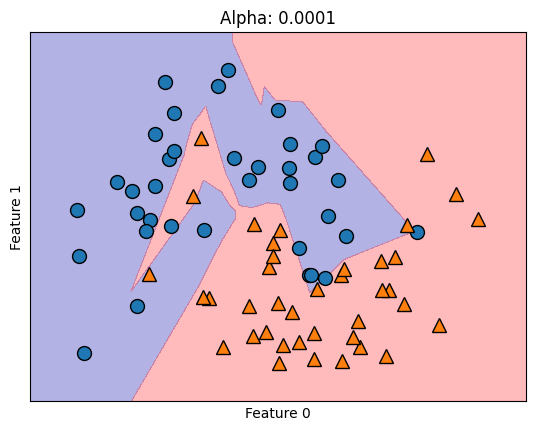

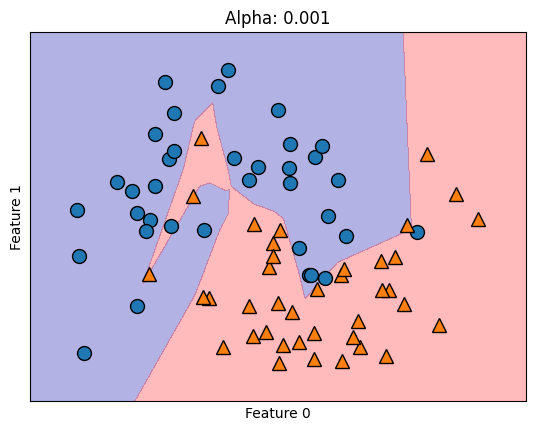

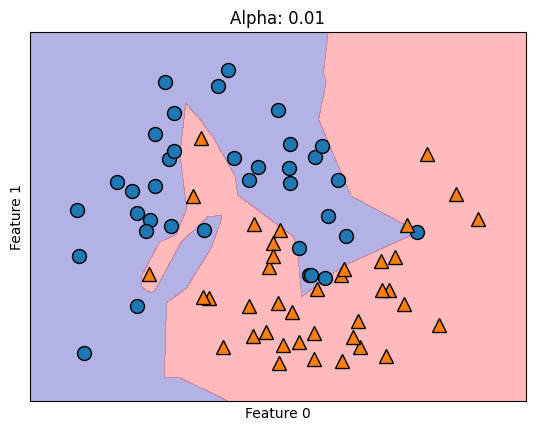

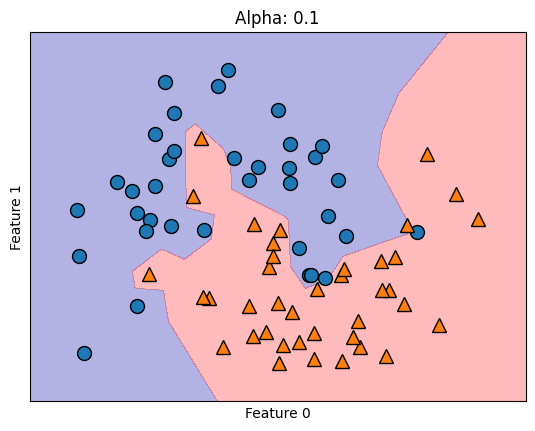

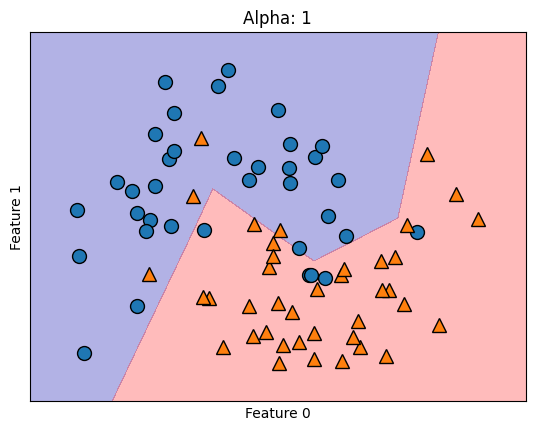

In [39]:

from sklearn.preprocessing import StandardScaler

# Prepare the data
X, y = make_moons(n_samples=100, noise=0.3, random_state=3)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Different alpha values to test
alphas = [0.0001, 0.001, 0.01, 0.1, 1]
for alpha in alphas:
    mlp = MLPClassifier(solver='lbfgs', alpha=alpha, random_state=1,
                        hidden_layer_sizes=[10, 10], max_iter=1000)
    mlp.fit(X_train_scaled, y_train)

    plt.figure()
    plt.title(f'Alpha: {alpha}')
    mglearn.plots.plot_2d_separator(mlp, X_train_scaled, fill=True, alpha=0.3)
    mglearn.discrete_scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], y_train)
    plt.xlabel("Feature 0")
    plt.ylabel("Feature 1")
    plt.show()


**4.	Discuss the effect of alpha**

Low Alpha Values (e.g., 0.0001, 0.001): The decision boundaries are more flexible, potentially fitting the training data very closely. This flexibility can capture complex patterns but risks overfitting, particularly if the dataset includes noise or non-representative data points.

High Alpha Values (e.g., 0.1, 1): The decision boundaries become smoother and simpler, reflecting the model’s focus on broader trends in the data. This simplicity helps in generalizing to new data but might underfit the training data, missing some nuances of the data distribution.

**Part 2. Build a NNET model to classify the Breast Cancer Data**

To get a better understanding of neural networks on real-world data, let’s apply the
MLPClassifier to the Breast Cancer dataset.

1.	(page 116) produce the training and test accuracies with MLPClassifier

In [40]:
from sklearn.datasets import load_breast_cancer
# Load data
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, random_state=0)

# Initialize MLPClassifier with default parameters
mlp = MLPClassifier(random_state=42)
mlp.fit(X_train, y_train)

# Evaluate the model
training_accuracy = mlp.score(X_train, y_train)
test_accuracy = mlp.score(X_test, y_test)
print(f"Accuracy on training set: {training_accuracy:.2f}")
print(f"Accuracy on test set: {test_accuracy:.2f}")

Accuracy on training set: 0.94
Accuracy on test set: 0.92


Neural networks typically perform better when input features are scaled or standardized. This step ensures that features contribute equally to the model's learning process, which is crucial for achieving high accuracy.


1.	Use StandardScaler to standardize the data to improve accuracy

In [41]:

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Re-train the MLPClassifier with scaled data
mlp = MLPClassifier(random_state=42)
mlp.fit(X_train_scaled, y_train)

# Evaluate the model with scaled data
scaled_training_accuracy = mlp.score(X_train_scaled, y_train)
scaled_test_accuracy = mlp.score(X_test_scaled, y_test)
print(f"Accuracy on scaled training set: {scaled_training_accuracy:.3f}")
print(f"Accuracy on scaled test set: {scaled_test_accuracy:.3f}")


Accuracy on scaled training set: 0.993
Accuracy on scaled test set: 0.965


/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


As there is
some gap between the training and the test performance, we might try to decrease the
model’s complexity to get better generalization performance. Here, we choose to
increase the alpha parameter (quite aggressively, from 0.0001 to 1) to add stronger
regularization of the weights

In [42]:
# Fine-tuning alpha parameter
alphas = [0.0001, 0.001, 0.01, 0.1, 1]
for alpha in alphas:
    mlp = MLPClassifier(max_iter=1000, alpha=alpha, random_state=42)
    mlp.fit(X_train_scaled, y_train)
    print(f"Alpha: {alpha}")
    print("Accuracy on training set: {:.3f}".format(mlp.score(X_train_scaled, y_train)))
    print("Accuracy on test set: {:.3f}".format(mlp.score(X_test_scaled, y_test)))


Alpha: 0.0001
Accuracy on training set: 1.000
Accuracy on test set: 0.965
Alpha: 0.001
Accuracy on training set: 1.000
Accuracy on test set: 0.965
Alpha: 0.01
Accuracy on training set: 0.998
Accuracy on test set: 0.965
Alpha: 0.1
Accuracy on training set: 0.995
Accuracy on test set: 0.958
Alpha: 1
Accuracy on training set: 0.986
Accuracy on test set: 0.979


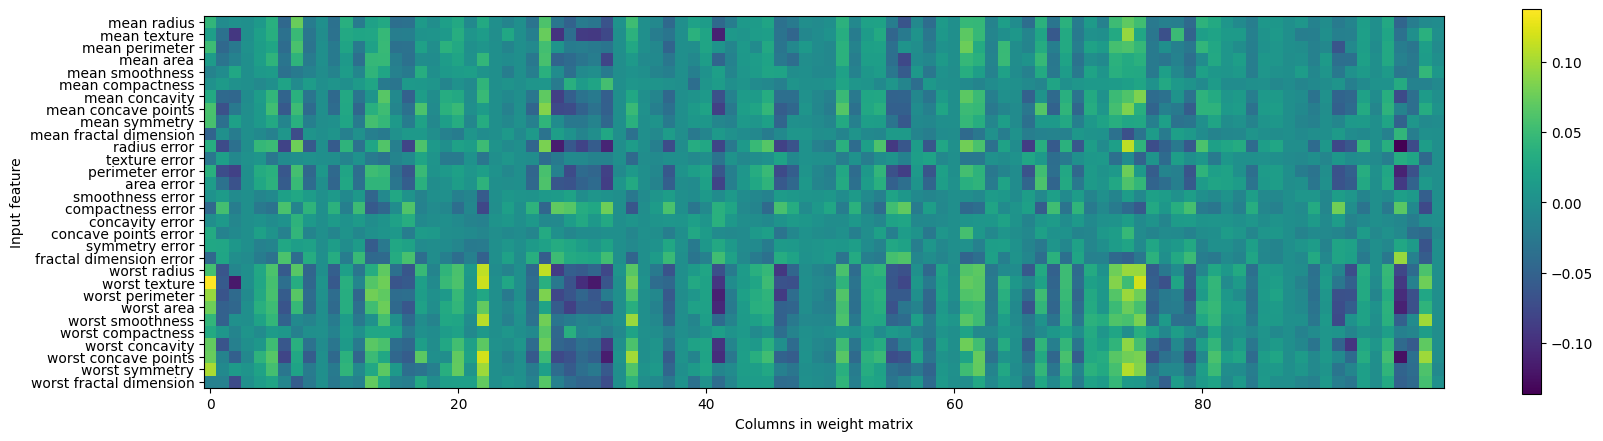

In [43]:
plt.figure(figsize=(20, 5))
plt.imshow(mlp.coefs_[0], interpolation='none', cmap='viridis')
plt.yticks(range(30), cancer.feature_names)
plt.xlabel("Columns in weight matrix")
plt.ylabel("Input feature")
plt.colorbar()


The optimal setting of alpha appears to be 1 for this specific dataset and MLP configuration. At this level, the model achieves the best balance between learning from the training data and generalizing to new, unseen data. This experiment underscores the importance of regularization in neural network training, particularly in preventing overfitting while striving for high accuracy in both training and testing phases. It highlights the necessity of tuning hyperparameters like alpha to tailor neural network models to specific datasets for optimal performance.